sample data

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


data = {
    "Age": [22, 23, 24, 25, 26, 27, 28, 29],

    "Salary": [25000, 30000, 32000, 35000,
               40000, 45000, 50000, 60000],

    "Experience": [1, 2, 2, 3, 4, 5, 6, 7],

    "Study_Hour": [2, 3, 4, 5, 6, 7, 8, 9],

    "Marks": [50, 55, 60, 65, 70, 78, 85, 95],

    "Gender": ["Male", "Female", "Male", "Female",
               "Male", "Male", "Female", "Female"],

    "Department": ["CSE", "EEE", "BBA", "CSE",
                   "EEE", "CSE", "BBA", "CSE"],

    "Attendance": [60, 65, 70, 75, 80, 85, 90, 95]
}


df = pd.DataFrame(data)
print(df)

   Age  Salary  Experience  Study_Hour  Marks  Gender Department  Attendance
0   22   25000           1           2     50    Male        CSE          60
1   23   30000           2           3     55  Female        EEE          65
2   24   32000           2           4     60    Male        BBA          70
3   25   35000           3           5     65  Female        CSE          75
4   26   40000           4           6     70    Male        EEE          80
5   27   45000           5           7     78    Male        CSE          85
6   28   50000           6           8     85  Female        BBA          90
7   29   60000           7           9     95  Female        CSE          95


paiplot with hue

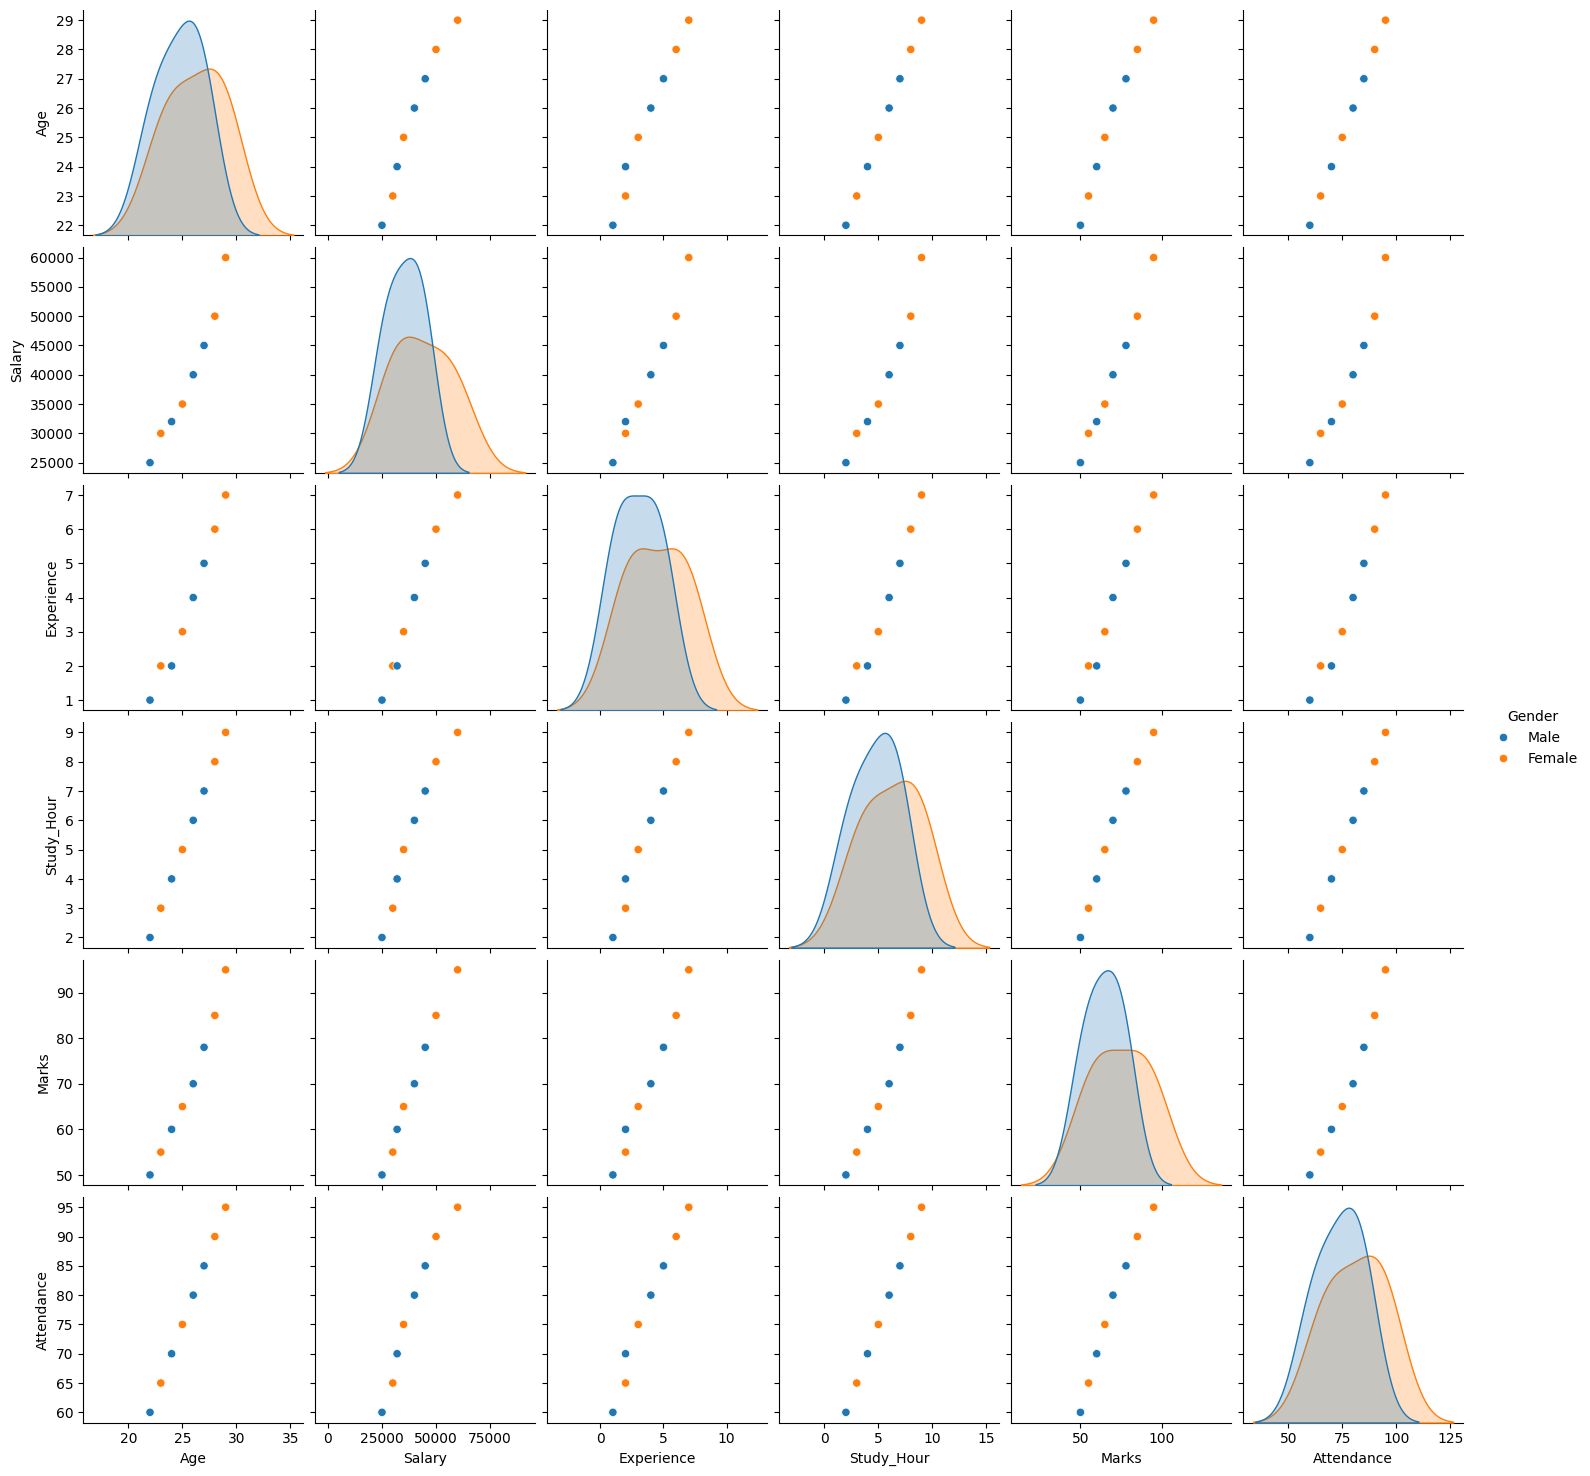

In [2]:
sns.pairplot(df, hue="Gender")

plt.show()

Multivariate Scatterplot

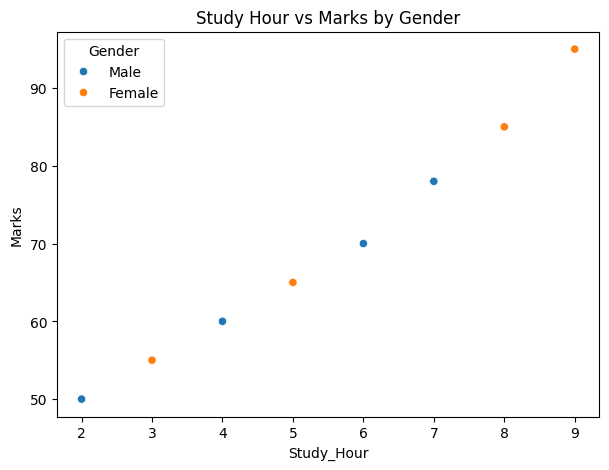

In [3]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df["Study_Hour"],
    y=df["Marks"],
    hue=df["Gender"]
)

plt.title("Study Hour vs Marks by Gender")

plt.show()

 Scatterplot with Size

Text(0.5, 1.0, 'Age vs Salary with Experience Size')

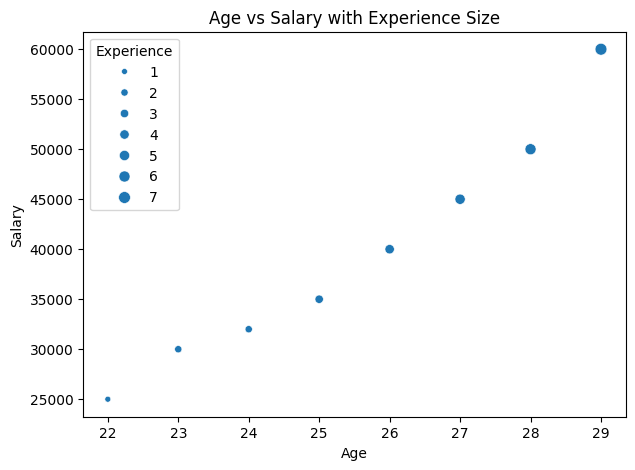

In [4]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df["Age"],
    y=df["Salary"],
    size=df["Experience"]
)

plt.title("Age vs Salary with Experience Size")


 Scatterplot with Style

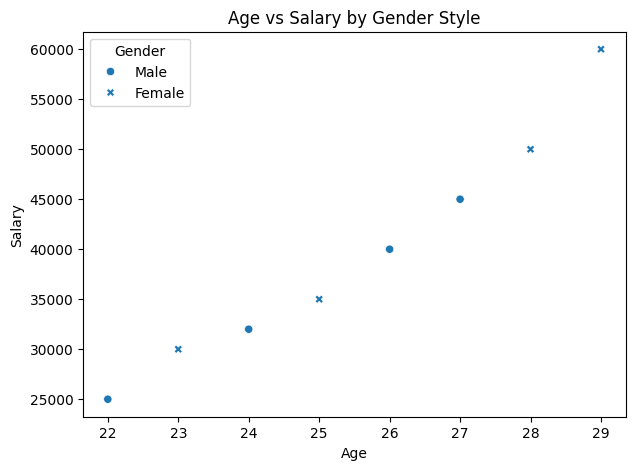

In [5]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df["Age"],
    y=df["Salary"],
    style=df["Gender"]
)

plt.title("Age vs Salary by Gender Style")

plt.show()


 Pivot Table

In [6]:
pivot_table = pd.pivot_table(
    df,
    values="Salary",
    index="Department",
    columns="Gender",
    aggfunc="mean"
)

print(pivot_table)

Gender       Female     Male
Department                  
BBA         50000.0  32000.0
CSE         47500.0  35000.0
EEE         30000.0  40000.0


 Advanced Groupby

In [7]:

group_result = df.groupby(
    ["Department", "Gender"]
)["Salary"].mean()

print(group_result)

Department  Gender
BBA         Female    50000.0
            Male      32000.0
CSE         Female    47500.0
            Male      35000.0
EEE         Female    30000.0
            Male      40000.0
Name: Salary, dtype: float64


Multiple Aggregation

In [8]:
agg_result = df.groupby(
    ["Department"]
)["Salary"].agg(
    ["mean", "max", "min", "std"]
)

print(agg_result)

               mean    max    min           std
Department                                     
BBA         41000.0  50000  32000  12727.922061
CSE         41250.0  60000  25000  14930.394056
EEE         35000.0  40000  30000   7071.067812


Heatmap using Correlation Matrix

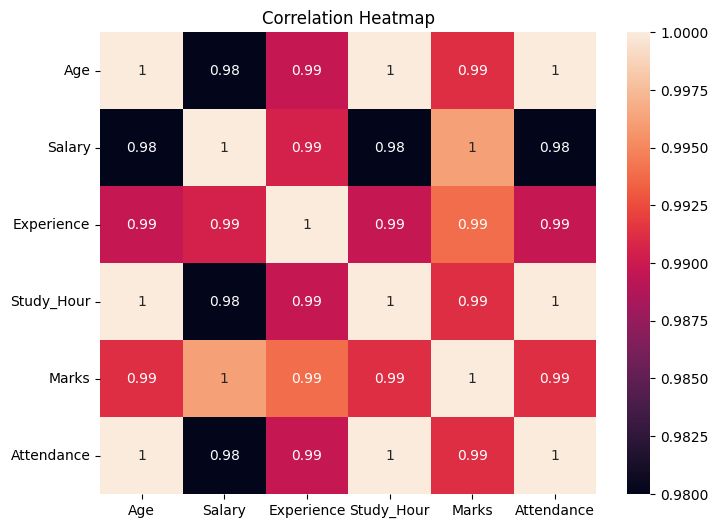

In [9]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()

Heatmap using Pivot Table

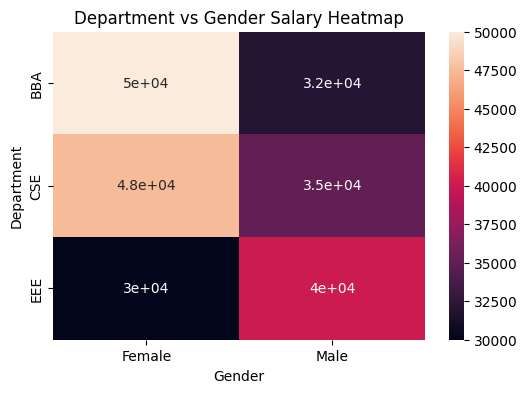

In [10]:
plt.figure(figsize=(6,4))

sns.heatmap(
    pivot_table,
    annot=True
)

plt.title("Department vs Gender Salary Heatmap")

plt.show()

 FacetGrid

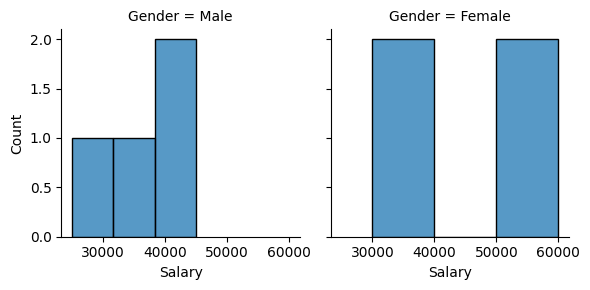

In [11]:
g = sns.FacetGrid(df, col="Gender")

g.map(sns.histplot, "Salary")

plt.show()

Crosstab Advanced

In [12]:
cross_tab = pd.crosstab(
    df["Gender"],
    df["Department"],
    margins=True
)

print(cross_tab)


Department  BBA  CSE  EEE  All
Gender                        
Female        1    2    1    4
Male          1    2    1    4
All           2    4    2    8


 Multivariate Outlier Detection

In [15]:
high_salary_low_exp = df[
    (df["Salary"] > 50000) &
    (df["Experience"] < 2)
]

print(high_salary_low_exp)

Empty DataFrame
Columns: [Age, Salary, Experience, Study_Hour, Marks, Gender, Department, Attendance]
Index: []


 Feature Interaction Example

In [16]:
interaction = df.groupby(
    ["Study_Hour", "Attendance"]
)["Marks"].mean()

print(interaction)

Study_Hour  Attendance
2           60            50.0
3           65            55.0
4           70            60.0
5           75            65.0
6           80            70.0
7           85            78.0
8           90            85.0
9           95            95.0
Name: Marks, dtype: float64
